<a href="https://colab.research.google.com/github/hectorjimenez12/CC5205_Proyecto/blob/main/Hito3_CNN%2B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimento 3 Proyecto Mineria de datos

In [19]:
import pandas as pd
import numpy as np
import random
import torch
from torch.utils.data import TensorDataset, DataLoader
from PIL import Image
from torchvision import datasets, models, transforms
import time
import copy
import torch.nn as nn
import torch.nn.functional as F
import torchvision

seed =  3495 #5937261 #  #123456

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True


# Cargar datos y descargar imagenes utilizadas

In [20]:
url = 'https://raw.githubusercontent.com/hectorjimenez12/Mineria_Datos/main/steam.csv'
dfdata = pd.read_csv(url)
url = 'https://raw.githubusercontent.com/hectorjimenez12/Mineria_Datos/main/steam_description_data.csv.zip'
df_descriptions = pd.read_csv(url)

In [21]:
def class_owners(strowners):
  own_int = int(strowners.split('-')[0])
  if own_int > 100000:
    return 'Hsell'
  else:
    return 'Lsell'
class_owners(dfdata.owners[100])

'Lsell'

<Axes: xlabel='owners_label'>

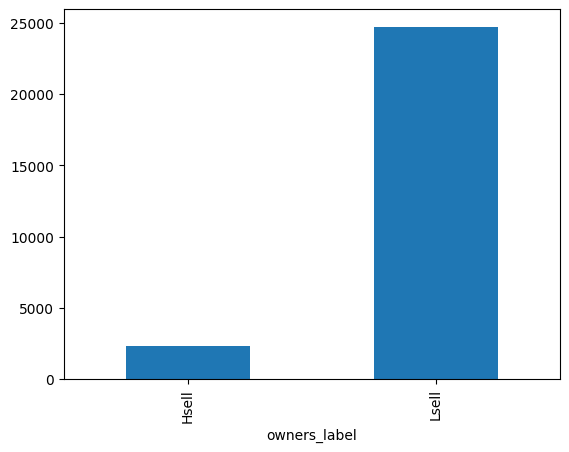

In [22]:
dfdata['owners_label'] = [ class_owners(i) for i in dfdata.owners ]
dfdata.groupby('owners_label').count().loc[:,'name'].plot.bar()

Seleccionamos un sample de 500 por cada clase

In [23]:
Nsample = 1000
labels = ['Hsell','Lsell']
list_ids = [ random.sample(list(dfdata.index[dfdata.owners_label.isin([i])]),k=Nsample) for i in labels ]
dfsample = dfdata.loc[ sum(list_ids,[]) , ['appid','name','genres','owners','owners_label'] ]
dfsample

,appid,name,genres,owners,owners_label
5923,377310,The Tower Of Elements,Action;Indie,200000-500000,Hsell
174,6870,Battlestations: Midway,Action,200000-500000,Hsell
1888,246900,Viscera Cleanup Detail,Indie;Simulation,500000-1000000,Hsell
14401,626690,Sword Art Online: Fatal Bullet,Action;RPG,200000-500000,Hsell
2775,285190,"Warhammer 40,000: Dawn of War III",Violent;Gore;Action;Simulation;Strategy,500000-1000000,Hsell
...,...,...,...,...,...
1600,227600,Castle of Illusion,Adventure;Casual,100000-200000,Lsell
20725,810680,Zombie Murder,Gore;Action;Casual;Indie,0-20000,Lsell
14612,635390,Thief of Thieves: Season One,Action;Adventure;Indie,0-20000,Lsell
8098,442890,Magic Potion Explorer,Casual;Indie;RPG;Strategy,0-20000,Lsell


In [24]:
list_img = []

for i in dfsample.appid:
  !wget https://cdn.cloudflare.steamstatic.com/steam/apps/{i}/header.jpg
  list_img.append(Image.open('header.jpg'))
  !rm header.jpg




Se truncaron las últimas líneas 5000 del resultado de transmisión.
Saving to: ‘header.jpg’

header.jpg          100%[===================>]  23.88K  --.-KB/s    in 0s      

2023-11-24 23:17:01 (142 MB/s) - ‘header.jpg’ saved [24458/24458]

--2023-11-24 23:17:01--  https://cdn.cloudflare.steamstatic.com/steam/apps/573410/header.jpg
Resolving cdn.cloudflare.steamstatic.com (cdn.cloudflare.steamstatic.com)... 104.18.42.105, 172.64.145.151
Connecting to cdn.cloudflare.steamstatic.com (cdn.cloudflare.steamstatic.com)|104.18.42.105|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 45429 (44K) [image/jpeg]
Saving to: ‘header.jpg’

header.jpg          100%[===================>]  44.36K  --.-KB/s    in 0.002s  

2023-11-24 23:17:01 (23.9 MB/s) - ‘header.jpg’ saved [45429/45429]

--2023-11-24 23:17:02--  https://cdn.cloudflare.steamstatic.com/steam/apps/993340/header.jpg
Resolving cdn.cloudflare.steamstatic.com (cdn.cloudflare.steamstatic.com)... 104.18.42.105, 172.64.145

# 1 Definicion de clases y transformaciones


In [25]:
class GamesDataset(torch.utils.data.Dataset):
  def __init__(self, dataX, dataY, transform):
    self.transform = transform
    self.class2idx = dict()
    self.class2idx['Lsell'] = 0
    self.class2idx['Hsell'] = 1

    self.classes = ['Lsell','Hsell']

    self.images = dataX
    self.labels = dataY

  def __len__(self):
    return len(self.images)

  def __getitem__(self, idx):
    #image = Image.open(image_path)
    label = self.class2idx[self.labels[idx]]
    im = self.images[idx].convert('RGB')

    if self.transform:
      image = self.transform(im)

    return image, label

In [ ]:
transforms = torchvision.transforms.Compose([torchvision.transforms.Resize(256),
                                 torchvision.transforms.CenterCrop(224),
                                 torchvision.transforms.ToTensor(),
                                 torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                                      std=[0.229, 0.224, 0.225]) ] )

Split dataset en train, validation y test

In [ ]:
from sklearn.model_selection import train_test_split
ylabel = list(dfsample['owners_label'])
X_train, X_test, Y_train, Y_test = train_test_split(list_img, ylabel, test_size = 0.1, stratify = ylabel , random_state=seed)
X_train, X_val , Y_train, Y_val  = train_test_split(X_train, Y_train, test_size=10/90, stratify= Y_train, random_state=seed)

Hsell


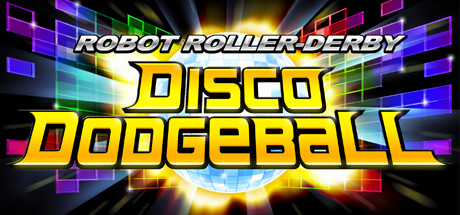

In [ ]:
print(Y_train[63])
X_train[63]

In [ ]:
# crear Games datasets
train_dataset = GamesDataset(dataX = X_train, dataY = Y_train , transform = transforms)
valid_dataset = GamesDataset(dataX = X_val, dataY = Y_val , transform = transforms)
test_dataset  = GamesDataset(dataX = X_test, dataY = Y_test , transform = transforms)
# dataloaders
batch_size = 50

train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
valid_loader = DataLoader(valid_dataset, shuffle=True, batch_size=batch_size)
test_loader  = DataLoader(test_dataset, shuffle=False, batch_size=1)

In [ ]:
# Chequear si tenemos GPU
train_on_gpu=torch.cuda.is_available()
if(train_on_gpu):
    print('Training on GPU.')
else:
    print('No GPU available, training on CPU.')

Training on GPU.


# 3. Entrenamiento de modelo preentrenado

In [ ]:
def train_model(model,criterio,optimizer,scheduler,train_loader,train_data,val_loader,val_data,num_epochs = 100):
  since = time.time()
  best_model_wts = copy.deepcopy(model.state_dict())
  best_acc = 0.0
  best_acc_train = 0.0
  best_acc_val = 0.0
  for epoch in range(num_epochs):
    print('Epoch {}/{}'.format(epoch, num_epochs-1))
    #print('-' * 10)
    #Train model
    scheduler.step()
    model.train()
    running_loss = 0.0
    running_corrects = 0.0
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
    epoch_loss = running_loss /len(train_data)
    epoch_acc_train = running_corrects.double() / len(train_data)
    print('Train Loss: {:.4f} Acc: {:.4f}'.format(epoch_loss, epoch_acc_train))
    #Validation
    model.eval()
    running_loss = 0.0
    running_corrects = 0.0
    for inputs, labels in val_loader:
      inputs = inputs.to(device)
      labels = labels.to(device)
      with torch.set_grad_enabled(False):
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)
      running_loss += loss.item() * inputs.size(0)
      running_corrects += torch.sum(preds == labels.data)
    epoch_loss = running_loss /len(val_data)
    epoch_acc = running_corrects.double() / len(val_data)
    print('Val Loss: {:.4f} Acc: {:.4f}'.format(epoch_loss, epoch_acc))
    if epoch_acc > best_acc:
        best_acc_train = epoch_acc_train
        best_acc = epoch_acc
        best_acc_val = epoch_acc
        best_model_wts = copy.deepcopy(model.state_dict())
    if float(epoch_acc_train) - float(epoch_acc)  > 0.3:
      print('early stopping at epoch ',epoch)
      print(epoch_acc_train)
      print(epoch_acc)
      break
  time_elapsed = time.time() - since
  print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed//60, time_elapsed % 60))
  print('Best val accucary: {:.4f}'.format(best_acc))
  print('Best train accucary: {:.4f}'.format(best_acc_train))
  print('--------------------------------------')
  print('--------------------------------------')
  print('--------------------------------------')
  model.load_state_dict(best_model_wts)
  return model,best_acc_train,best_acc_val

In [ ]:
def predict_test(model,test_data):
    #Test
    model.eval()
    running_corrects = 0.0
    for inputs, labels in test_loader:
      inputs = inputs.to(device)
      labels = labels.to(device)

      with torch.set_grad_enabled(False):
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)
        #print(outputs)

      running_corrects += torch.sum(preds == labels.data)
      #print(running_corrects)

    acc_test = running_corrects.double() / len(test_data)
    return acc_test

In [ ]:
device = ('cuda' if torch.cuda.is_available() else 'cpu')

In [29]:
rs= models.resnet18(pretrained=True)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [32]:
pretrained = copy.deepcopy(rs)
nweights = 1000
pretrained.classifier = nn.Sequential(nn.Linear(512 * 7 * 7, nweights),
                            nn.ReLU(True),
                            nn.BatchNorm1d(nweights),
                            nn.Dropout(p=0.8),
                            nn.Linear(nweights, nweights),
                            nn.ReLU(True),
                            nn.BatchNorm1d(nweights),
                            nn.Dropout(p=0.8),
                            nn.Linear(nweights, 2),)
pretrained = pretrained.to(device)
criterion = nn.CrossEntropyLoss()
#optimizer = torch.optim.SGD( pretrained.parameters(),lr = 0.001,momentum = 0.8 )
optimizer = torch.optim.Adam(pretrained.parameters(), lr=0.001) #, momentum=0.9
exp_lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)
trained, tacc,vacc = train_model(pretrained, criterion, optimizer, exp_lr_scheduler,
                                 train_loader = train_loader, train_data= train_dataset,
                                 val_loader = valid_loader, val_data=valid_dataset, num_epochs = 10)
testacc = predict_test(model = trained, test_data = test_dataset)


Epoch 0/9


/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:136: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn("Detected call of `lr_scheduler.step()` before `optimizer.step()`. "


Train Loss: 2.2293 Acc: 0.4825
Val Loss: 2.2022 Acc: 0.5000
Epoch 1/9
Train Loss: 0.6802 Acc: 0.5975
Val Loss: 0.6902 Acc: 0.5700
Epoch 2/9
Train Loss: 0.6297 Acc: 0.6581
Val Loss: 0.7129 Acc: 0.5200
Epoch 3/9
Train Loss: 0.5781 Acc: 0.6794
Val Loss: 0.8746 Acc: 0.5000
Epoch 4/9
Train Loss: 0.5002 Acc: 0.7538
Val Loss: 0.9635 Acc: 0.5450
Epoch 5/9
Train Loss: 0.4076 Acc: 0.8163
Val Loss: 1.0879 Acc: 0.5600
Epoch 6/9
Train Loss: 0.2418 Acc: 0.9012
Val Loss: 1.0342 Acc: 0.5500
early stopping at epoch  6
tensor(0.9012, device='cuda:0', dtype=torch.float64)
tensor(0.5500, device='cuda:0', dtype=torch.float64)
Training complete in 1m 23s
Best val accucary: 0.5700
Best train accucary: 0.5975
--------------------------------------
--------------------------------------
--------------------------------------


Freezing

In [33]:
rs = models.vgg19(pretrained = True)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth
100%|██████████| 548M/548M [00:17<00:00, 33.4MB/s]


In [35]:
pretrained = copy.deepcopy(rs)

for param in pretrained.parameters():
    param.requires_grad = False

nweights = 4000
pretrained.classifier = nn.Sequential(nn.Linear(512 * 7 * 7, nweights),
                            nn.ReLU(True),
                            nn.BatchNorm1d(nweights),
                            nn.Dropout(p=0.5),
                            nn.Linear(nweights, nweights),
                            nn.ReLU(True),
                            nn.BatchNorm1d(nweights),
                            nn.Dropout(p=0.5),
                            nn.Linear(nweights, 2),)
pretrained = pretrained.to(device)
criterion = nn.CrossEntropyLoss()
#optimizer = torch.optim.SGD( pretrained.parameters(),lr = 0.001,momentum = 0.8 )
optimizer = torch.optim.Adam(pretrained.classifier.parameters(), lr=0.001) #, momentum=0.9
exp_lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)
trained, tacc,vacc = train_model(pretrained, criterion, optimizer, exp_lr_scheduler,
                                 train_loader = train_loader, train_data= train_dataset,
                                 val_loader = valid_loader, val_data=valid_dataset, num_epochs = 10)
testacc = predict_test(model = trained, test_data = test_dataset)



tensor(0.6200, device='cuda:0', dtype=torch.float64)